In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes

In [3]:
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [4]:
t = np.linspace(1*4,(1+1)*4,N) + np.random.randn(N)*0.2
print(t[-10:])

[7.93695777 7.52532653 7.69581138 7.81315906 7.80816054 7.45586846
 7.77972304 7.6681281  7.96105783 8.26047057]


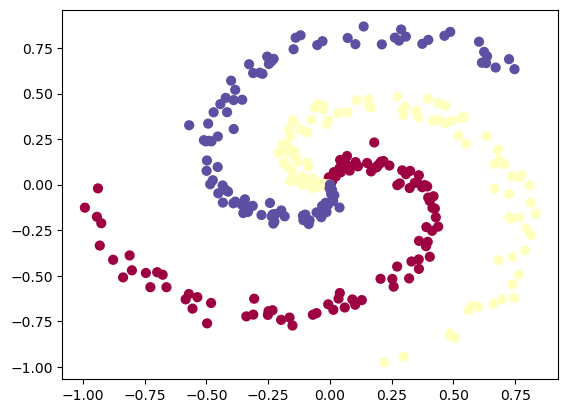

In [5]:
for j in range(K): # for each class
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*(4.5),(j+1)*(4.5),N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data:
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [8]:
W=0.01 * np.random.randn(D,K)
b=np.zeros((1,K))

print(W.shape)
print(b.shape)

(2, 3)
(1, 3)


In [9]:
scores=np.dot(X,W) + b
print(scores.shape)

(300, 3)


## SVM

In [ ]:
#SVM
mgn=1
s=scores-scores[np.arange(N*K), y].reshape(-1,1)
margin=np.maximum(0, np.sum(s,axis=1) + mgn)
print(margin.shape)
print(np.mean(margin, axis=0))

(300,)
1.0016864182228282


## Softmax linear classifier

In [10]:
# Softmax
exp_scores = np.exp(scores)
probs= exp_scores/ np.sum(exp_scores, axis=1, keepdims=True)
print(probs.shape)

(300, 3)


In [11]:
losses= -np.log(probs[np.arange(N*K), y])
# correct_logprobs = -np.log(probs[range(N*K),y])


In [16]:
data_loss=np.sum(losses,axis=0)/(N*K)
reg = 1e-3
regulation_loss=0.5*reg*np.sum(W*W)
total_loss=data_loss + regulation_loss
## 여기까지 feed forward

In [17]:
print(regulation_loss.shape)

()


In [ ]:
#gradient
dscores=probs
dscores[np.arange(N*K),y]-=1
dscores/=(N*K)



In [ ]:
dW=np.dot(X.T, dscores)
db=np.sum(dscores, axis=0, keepdims=True)

In [20]:
#initiallize
W=0.01 * np.random.randn(D,K)
b=np.zeros((1,K))

lr=1e-0
reg=1e-3

epochs=200

for i in range(epochs):
    scores=np.dot(X,W) + b
    # Softmax
    exp_scores = np.exp(scores)
    probs= exp_scores/ np.sum(exp_scores, axis=1, keepdims=True)

    # loss(negative log-likeli hood)
    losses= -np.log(probs[np.arange(N*K), y])
    data_loss=np.sum(losses,axis=0)/(N*K)
    regulation_loss=0.5*reg*np.sum(W*W)
    total_loss=data_loss + regulation_loss
    if i % 10 == 0:
        print("iteration %d: loss %f" % (i, total_loss))

    #gradient
    dscore=probs
    dscore[np.arange(N*K),y]-=1
    dscore/=(N*K)
    dW=np.dot(X.T, dscore)
    dW+=reg*W
    db=np.sum(dscore, axis=0, keepdims=True)

    #backpropagation
    W-=lr*dW
    b-=lr*db



iteration 0: loss 1.099666
iteration 10: loss 0.954562
iteration 20: loss 0.901926
iteration 30: loss 0.879190
iteration 40: loss 0.868060
iteration 50: loss 0.862118
iteration 60: loss 0.858742
iteration 70: loss 0.856733
iteration 80: loss 0.855496
iteration 90: loss 0.854714
iteration 100: loss 0.854208
iteration 110: loss 0.853876
iteration 120: loss 0.853655
iteration 130: loss 0.853506
iteration 140: loss 0.853406
iteration 150: loss 0.853337
iteration 160: loss 0.853290
iteration 170: loss 0.853258
iteration 180: loss 0.853236
iteration 190: loss 0.853220


In [ ]:
#Train a Linear Classifier

# initialize parameters randomly
W = 0.01 * np.random.randn(D,K)
b = np.zeros((1,K))

# some hyperparameters
step_size = 1e-0
reg = 1e-3 # regularization strength

# gradient descent loop
num_examples = X.shape[0]
for i in range(200):

  # evaluate class scores, [N x K]
  scores = np.dot(X, W) + b

  # compute the class probabilities
  exp_scores = np.exp(scores)
  probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True) # [N x K]

  # compute the loss: average cross-entropy loss and regularization
  correct_logprobs = -np.log(probs[range(num_examples),y])
  data_loss = np.sum(correct_logprobs)/num_examples
  reg_loss = 0.5*reg*np.sum(W*W)
  loss = data_loss + reg_loss
  if i % 10 == 0:
    print "iteration %d: loss %f" % (i, loss)

  # compute the gradient on scores
  dscores = probs
  dscores[range(num_examples),y] -= 1
  dscores /= num_examples

  # backpropate the gradient to the parameters (W,b)
  dW = np.dot(X.T, dscores)
  db = np.sum(dscores, axis=0, keepdims=True)

  dW += reg*W # regularization gradient

  # perform a parameter update
  W += -step_size * dW
  b += -step_size * db

In [22]:
scores = np.dot(X, W) + b
predicted_class = np.argmax(scores, axis=1)
print ("training accuracy: %.2f" % (np.mean(predicted_class == y)))

training accuracy: 0.47


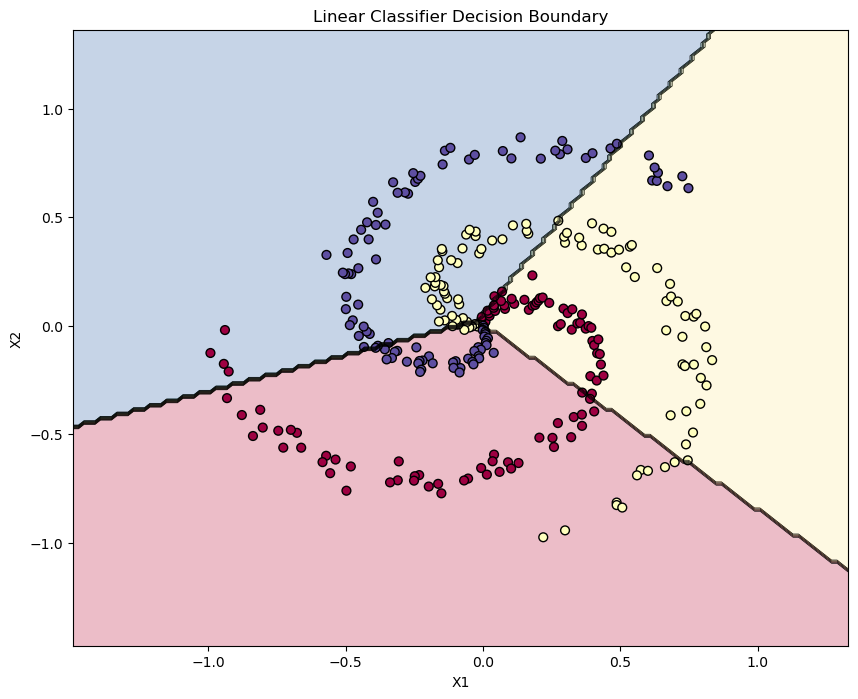

In [23]:
# 결정 경계 시각화

# 그리드 생성
h = 0.02  # 메쉬 그리드 해상도
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 그리드 포인트에 대해 예측
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_scores = np.dot(grid_points, W) + b
grid_pred = np.argmax(grid_scores, axis=1)
grid_pred = grid_pred.reshape(xx.shape)

# 시각화
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, grid_pred, alpha=0.3, cmap=plt.cm.Spectral)
plt.contour(xx, yy, grid_pred, colors='k', linewidths=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral, edgecolors='k')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title('Linear Classifier Decision Boundary')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

## Neural Network

In [27]:
#initiallize
H=100
W1=0.01 * np.random.randn(D,H)
b1=np.zeros((1,H))
W2=0.01 * np.random.randn(H,K)
b2=np.zeros((1,K))

lr=1e-0
reg=1e-3

epochs=10000

for i in range(epochs):
    hidden_layer=np.maximum(0,np.dot(X,W1)+b1)
    scores=np.dot(hidden_layer,W2) + b2
    # Softmax
    exp_scores = np.exp(scores)
    probs= exp_scores/ np.sum(exp_scores, axis=1, keepdims=True)

    # loss(negative log-likeli hood)
    losses= -np.log(probs[np.arange(N*K), y])
    data_loss=np.sum(losses,axis=0)/(N*K)
    regulation_loss=0.5*reg*np.sum(W*W)
    total_loss=data_loss + regulation_loss
    if i % 10 == 0:
        print("iteration %d: loss %f" % (i, total_loss))

    #gradient
    dscore=probs
    dscore[np.arange(N*K),y]-=1
    dscore/=(N*K)
    dW2=np.dot(hidden_layer.T, dscore)
    dW2+=reg*W2
    db2=np.sum(dscore,axis=0,keepdims=True)

    dhidden=np.dot(dscore,W2.T)
    dhidden[hidden_layer <= 0] = 0
    dW1=np.dot(X.T, dhidden)
    dW1+=reg*W1
    db1=np.sum(dhidden, axis=0, keepdims=True)
    db1=np.sum(dhidden, axis=0, keepdims=True)
    #backpropagation
    W1-=lr*dW1
    b1-=lr*db1
    W2-=lr*dW2
    b2-=lr*db2


iteration 0: loss 1.105836
iteration 10: loss 1.103132
iteration 20: loss 1.089172
iteration 30: loss 1.027241
iteration 40: loss 0.921433
iteration 50: loss 0.855369
iteration 60: loss 0.831818
iteration 70: loss 0.823459
iteration 80: loss 0.818182
iteration 90: loss 0.813268
iteration 100: loss 0.807861
iteration 110: loss 0.802077
iteration 120: loss 0.795834
iteration 130: loss 0.788955
iteration 140: loss 0.781182
iteration 150: loss 0.774560
iteration 160: loss 0.826051
iteration 170: loss 0.784310
iteration 180: loss 0.780748
iteration 190: loss 0.768056
iteration 200: loss 0.754466
iteration 210: loss 0.739126
iteration 220: loss 0.727750
iteration 230: loss 0.748311
iteration 240: loss 0.710152
iteration 250: loss 0.677172
iteration 260: loss 0.690708
iteration 270: loss 0.650301
iteration 280: loss 0.610224
iteration 290: loss 0.583478
iteration 300: loss 0.563680
iteration 310: loss 0.544530
iteration 320: loss 0.525178
iteration 330: loss 0.508715
iteration 340: loss 0.495

In [28]:
hidden_layer = np.maximum(0, np.dot(X, W1) + b1)
scores = np.dot(hidden_layer, W2) + b2
predicted_class = np.argmax(scores, axis=1)
print ("training accuracy: %.2f" % (np.mean(predicted_class == y)))

training accuracy: 0.98


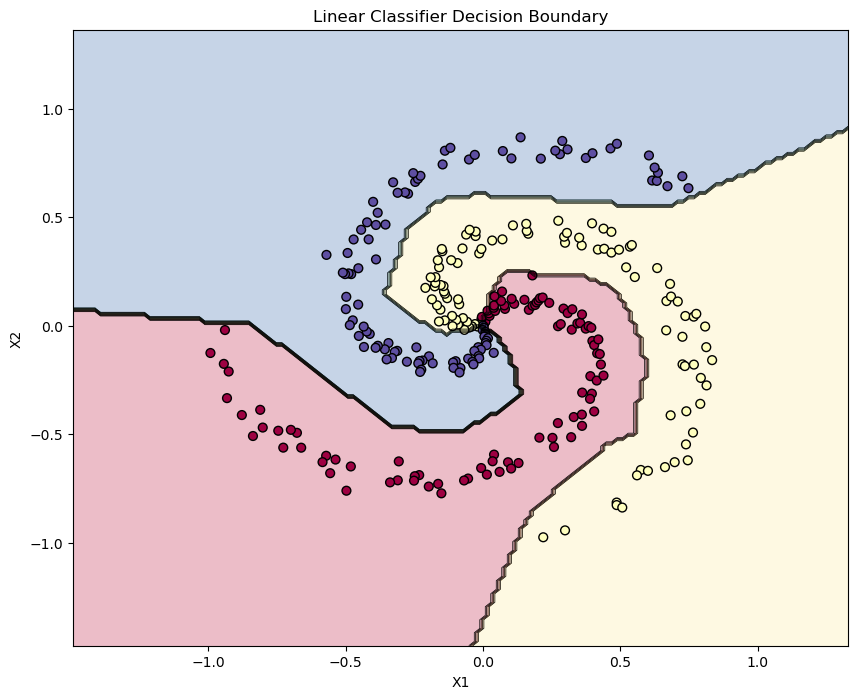

In [29]:
# 결정 경계 시각화

# 그리드 생성
h = 0.02  # 메쉬 그리드 해상도
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 그리드 포인트에 대해 예측
grid_points = np.c_[xx.ravel(), yy.ravel()]
hidden_layer_grid = np.maximum(0, np.dot(grid_points, W1) + b1)
grid_scores = np.dot(hidden_layer_grid, W2) + b2
grid_pred = np.argmax(grid_scores, axis=1)
grid_pred = grid_pred.reshape(xx.shape)

# 시각화
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, grid_pred, alpha=0.3, cmap=plt.cm.Spectral)
plt.contour(xx, yy, grid_pred, colors='k', linewidths=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral, edgecolors='k')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title('Linear Classifier Decision Boundary')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()